In [4]:
import pandas as pd

df = pd.read_csv("Amazon_Sales_.csv")

df.head()

,index,Order_ID,Date,Status,Fulfilment,Sales_Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed:_22
0,0,405-8078784-5731545,30-04-2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,30-04-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,30-04-2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
df.isnull().sum()

index                    0
Order_ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales_Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier_Status          82
Qty                      0
currency               158
Amount                 158
ship-city                2
ship-state               2
ship-postal-code         2
ship-country             2
promotion-ids          722
B2B                      0
fulfilled-by          1583
Unnamed:_22           2000
dtype: int64

In [9]:
df.ffill(inplace=True)
df.drop_duplicates(inplace=True)

In [10]:
df['Amount'].sum()

np.float64(1260816.5299999998)

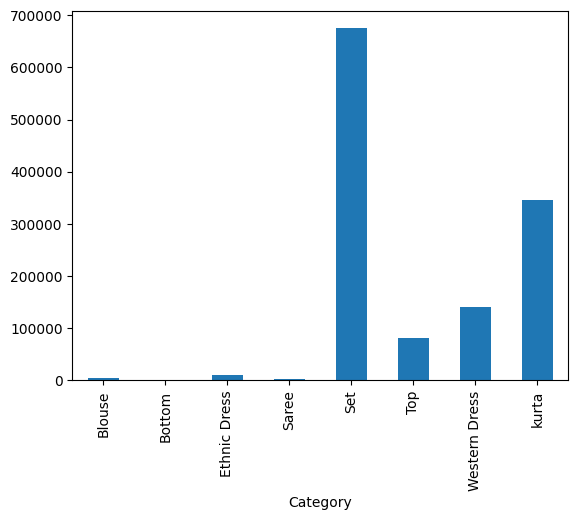

In [11]:
import matplotlib.pyplot as plt

df.groupby('Category')['Amount'].sum().plot(kind='bar')
plt.show()

In [13]:
df.to_csv("cleaned_data.csv", index=False)

In [14]:
df.columns
df.nunique()

index                 2000
Order_ID              1892
Date                     2
Status                   5
Fulfilment               2
Sales_Channel            2
ship-service-level       2
Style                  550
SKU                   1123
Category                 8
Size                    11
ASIN                  1123
Courier_Status           3
Qty                      4
currency                 1
Amount                 281
ship-city              614
ship-state              35
ship-postal-code      1133
ship-country             1
promotion-ids          111
B2B                      2
fulfilled-by             1
Unnamed:_22              0
dtype: int64

In [15]:
df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Set              674780.53
kurta            346710.14
Western Dress    140766.20
Top               80926.66
Ethnic Dress      10429.00
Blouse             4399.00
Saree              2428.00
Bottom              377.00
Name: Amount, dtype: float64

In [17]:
df.columns

Index(['index', 'Order_ID', 'Date', 'Status', 'Fulfilment', 'Sales_Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier_Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed:_22'],
      dtype='object')

In [19]:
df['SKU'].value_counts().head(10)

SKU
JNE3405-KR-L       25
J0341-DR-M         16
J0003-SET-M        15
JNE3373-KR-XXXL    14
JNE3405-KR-XL      14
JNE3405-KR-XXXL    13
J0003-SET-XXXL     12
SET324-KR-NP-L     12
J0230-SKD-S        12
SET345-KR-NP-M     12
Name: count, dtype: int64

In [20]:
df['Category'].value_counts().head(10)

Category
Set              833
kurta            778
Western Dress    200
Top              162
Ethnic Dress      13
Blouse            10
Saree              3
Bottom             1
Name: count, dtype: int64

In [21]:
df['Style'].value_counts().head(10)

Style
JNE3405    72
J0003      51
J0341      49
SET324     48
SET345     34
SET268     33
J0230      32
JNE3373    32
SET291     25
SET398     24
Name: count, dtype: int64

In [22]:
df['Category'].value_counts().head(10)

Category
Set              833
kurta            778
Western Dress    200
Top              162
Ethnic Dress      13
Blouse            10
Saree              3
Bottom             1
Name: count, dtype: int64

In [23]:
df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Set              674780.53
kurta            346710.14
Western Dress    140766.20
Top               80926.66
Ethnic Dress      10429.00
Blouse             4399.00
Saree              2428.00
Bottom              377.00
Name: Amount, dtype: float64

In [24]:
df['ship-city'].value_counts().head(10)

ship-city
BENGALURU    155
HYDERABAD    146
MUMBAI        86
CHENNAI       80
NEW DELHI     77
PUNE          50
KOLKATA       40
GURUGRAM      37
THANE         28
AHMEDABAD     27
Name: count, dtype: int64

In [25]:
df['Status'].value_counts()

Status
Shipped                         1366
Shipped - Delivered to Buyer     320
Cancelled                        299
Shipped - Returned to Seller      14
Shipped - Rejected by Buyer        1
Name: count, dtype: int64

In [27]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.groupby(df['Date'].dt.month)['Amount'].sum()

Date
4    1260816.53
Name: Amount, dtype: float64